# STUDENT PERFORMANCE PREDICTION
# Data Preprocessing & Feature Engineering

In [1]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/redheadcoffee/student-performance-prediction-synthetic-dataset/student_performance_synthetic_clean.csv


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
df = pd.read_csv(
    "/kaggle/input/datasets/redheadcoffee/student-performance-prediction-synthetic-dataset/student_performance_synthetic_clean.csv"
)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (2000, 13)


,StudentID,Name,Age,Gender,AttendancePct,StudyHoursPerWeek,PreviousGrade,AssignmentMarks,InternalAssessmentMarks,OnlineClasses,ExtracurricularActivities,ParentalSupport,FinalExamMarks
0,STU10001,Allison Hill,23,Male,88.60,7.78,85.35,53.76,67.11,Yes,1,Medium,68.20
1,STU10002,Noah Rhodes,20,Female,84.17,20.28,65.60,59.41,52.96,Yes,0,Low,52.83
2,STU10003,Angie Henderson,21,Female,84.84,18.51,62.42,62.05,59.86,No,2,Medium,65.05
3,STU10004,Daniel Wagner,23,Female,64.34,9.96,62.85,54.59,49.67,No,1,Medium,48.23
4,STU10005,Cristian Santos,19,Female,90.12,22.43,62.21,76.58,70.07,No,0,Medium,68.26


Initial validation

In [4]:
print("Shape:", df.shape)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDuplicate Student IDs:")
print(df["StudentID"].duplicated().sum())

print("\nData types:")
display(df.dtypes)

Shape: (2000, 13)

Missing values:


StudentID                    0
Name                         0
Age                          0
Gender                       0
AttendancePct                0
StudyHoursPerWeek            0
PreviousGrade                0
AssignmentMarks              0
InternalAssessmentMarks      0
OnlineClasses                0
ExtracurricularActivities    0
ParentalSupport              0
FinalExamMarks               0
dtype: int64


Duplicate rows:
0

Duplicate Student IDs:
0

Data types:


StudentID                     object
Name                          object
Age                            int64
Gender                        object
AttendancePct                float64
StudyHoursPerWeek            float64
PreviousGrade                float64
AssignmentMarks              float64
InternalAssessmentMarks      float64
OnlineClasses                 object
ExtracurricularActivities      int64
ParentalSupport               object
FinalExamMarks               float64
dtype: object

Define modelling roles

In [5]:
id_cols = [
    "StudentID",
    "Name"
]

target_col = "FinalExamMarks"

base_features = [
    "Age",
    "Gender",
    "AttendancePct",
    "StudyHoursPerWeek",
    "PreviousGrade",
    "AssignmentMarks",
    "InternalAssessmentMarks",
    "OnlineClasses",
    "ExtracurricularActivities",
    "ParentalSupport"
]

# Feature engineering

Continuous assessment average

In [6]:
df["ContinuousAssessmentAverage"] = (
    df["AssignmentMarks"] +
    df["InternalAssessmentMarks"]
) / 2

Performance Trend

In [7]:
# Performance Trend
df["PerformanceTrend"] = (
    df["ContinuousAssessmentAverage"] -
    df["PreviousGrade"]
)

Attendance–study interaction

In [8]:
df["AttendanceStudyInteraction"] = (
    df["AttendancePct"] *
    df["StudyHoursPerWeek"]
)

In [9]:
engineered_features = [
    "ContinuousAssessmentAverage",
    "PerformanceTrend",
    "AttendanceStudyInteraction"
]

# checking whether the engineered features make sense

In [10]:
analysis_cols = [
    "AttendancePct",
    "StudyHoursPerWeek",
    "PreviousGrade",
    "AssignmentMarks",
    "InternalAssessmentMarks",
    "ContinuousAssessmentAverage",
    "PerformanceTrend",
    "AttendanceStudyInteraction",
    "FinalExamMarks"
]

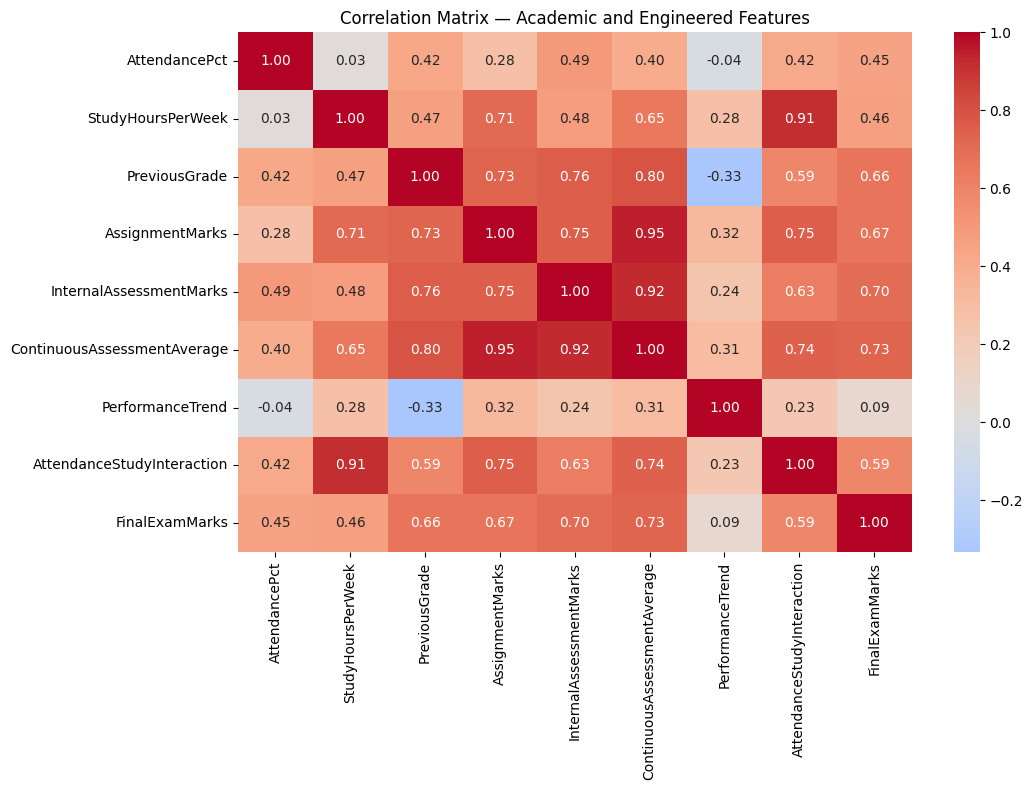

In [11]:
corr = df[analysis_cols].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix — Academic and Engineered Features")
plt.tight_layout()
plt.show()

In [12]:
output_path = "/kaggle/working/student_performance_feature_engineered_v2.csv"

df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

Saved: /kaggle/working/student_performance_feature_engineered_v2.csv
